<a href="https://colab.research.google.com/github/Gsusjs/carisurg-portfolio/blob/main/notebooks/Week6_Tutorial2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
# Week 6 - Logistic Regression and Decision Trees

# Aim

# The aim of this notebook is to develop and compare two baseline machine learning models for predicting a patient's Emergency Severity Index (ESI) level using emergency department triage data. The models implemented are Logistic Regression and Decision Tree classifiers.

# This notebook covers the complete machine learning workflow, including preparing the dataset, splitting the data into training and testing sets, training baseline models, evaluating their performance, visualising model decisions, and saving the trained models for future use.

In [50]:

## Import Libraries

# The required Python libraries are imported for data processing, machine learning, visualisation, and saving trained models. These tools allow the dataset to be prepared, models to be trained, and results to be analysed.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.dummy import DummyClassifier


pd.set_option("display.width", 120)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [51]:
## Load Dataset

# The cleaned Yale EMMLC triage dataset is loaded into a pandas DataFrame. The dataset is checked to confirm the number of patient records and available features.
df = pd.read_csv("yaleemmlc_admissionprediction_triage.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (55121, 226)


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [52]:
## Feature Selection

# The target variable for prediction is the Emergency Severity Index (ESI). The input features are selected from the available patient information, while variables that could cause data leakage are removed because they would not be available at the time of triage.
TARGET = "esi"

VITALS = [
    "triage_vital_hr",
    "triage_vital_sbp",
    "triage_vital_dbp",
    "triage_vital_rr",
    "triage_vital_o2",
    "triage_vital_temp",
    "triage_glucose"
]

DEMOGRAPHICS = [
    "age",
    "gender",
    "ethnicity",
    "race",
    "lang",
    "religion",
    "maritalstatus",
    "employstatus",
    "insurance_status"
]

ADMIN = [
    "dep_name",
    "arrivalmode",
    "arrivalmonth",
    "arrivalday",
    "arrivalhour_bin"
]

LEAKAGE = [
    "disposition",
    "previousdispo"
]


FEATURES = [
    c for c in df.columns
    if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS
]


X = df[FEATURES]
y = df[TARGET]


print("Number of features:", len(FEATURES))

Number of features: 209


In [53]:
## Split dataset into training and testing sets

# The dataset is divided into training and testing groups. The training data is used for learning patterns, while the testing data is used to evaluate how well the models perform on unseen patient records.

# A stratified split is applied to maintain a similar distribution of ESI classes in both datasets, and a fixed random state is used to ensure reproducibility.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


print("Training patients:", X_train.shape[0])
print("Testing patients:", X_test.shape[0])

Training patients: 44096
Testing patients: 11025


In [54]:
## Baseline Model: Dummy Classifier

# A Dummy Classifier is created to provide a baseline level of performance. This model acts as a reference point because it does not learn complex relationships from the data.

# The trained machine learning models should achieve better performance than this baseline.

dummy = DummyClassifier(
    strategy="stratified",
    random_state=42
)

dummy.fit(X_train, y_train)

dummy_accuracy = dummy.score(X_test, y_test)

print("Dummy Accuracy:", dummy_accuracy)

Dummy Accuracy: 0.37541950113378686


In [55]:
## Logistic Regression Model

# A Logistic Regression model is trained to predict ESI levels from the selected features.

# Before training, feature scaling is applied using StandardScaler because Logistic Regression is influenced by differences in feature ranges. Scaling ensures that features contribute more equally during model training.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


logreg = LogisticRegression(
    max_iter=1000,
    random_state=42
)


logreg.fit(
    X_train_scaled,
    y_train
)


logreg_accuracy = logreg.score(
    X_test_scaled,
    y_test
)


print("Logistic Regression Accuracy:", logreg_accuracy)

Logistic Regression Accuracy: 0.6669387755102041


In [56]:
## Decision Tree Model

# A Decision Tree classifier is trained using the original feature values.

# Unlike Logistic Regression, Decision Trees do not require feature scaling because they make decisions using feature-based split points. The tree depth is limited to reduce overfitting and improve interpretability.
tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)


tree.fit(
    X_train,
    y_train
)


tree_accuracy = tree.score(
    X_test,
    y_test
)


print("Decision Tree Accuracy:", tree_accuracy)

Decision Tree Accuracy: 0.5559183673469388


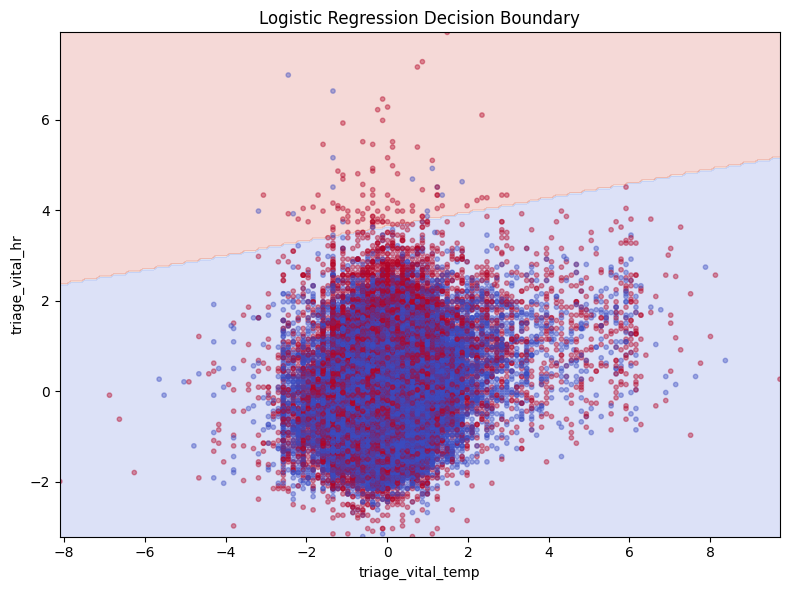

In [57]:
## Logistic Regression Visualisation

# The Logistic Regression decision boundary is visualised using two selected vital-sign features. This provides an example of how the model separates urgent and non-urgent patient cases.

f1 = "triage_vital_temp"
f2 = "triage_vital_hr"


urgent = (y <= 2).astype(int)


two_features = StandardScaler().fit_transform(
    X[[f1, f2]]
)


demo = LogisticRegression(
    max_iter=1000
)

demo.fit(
    two_features,
    urgent
)


xx, yy = np.meshgrid(
    np.linspace(two_features[:,0].min(), two_features[:,0].max(), 200),
    np.linspace(two_features[:,1].min(), two_features[:,1].max(), 200)
)


zz = demo.predict(
    np.c_[xx.ravel(), yy.ravel()]
).reshape(xx.shape)


plt.figure(figsize=(8,6))

plt.contourf(
    xx,
    yy,
    zz,
    alpha=0.2,
    cmap="coolwarm"
)

plt.scatter(
    two_features[:,0],
    two_features[:,1],
    c=urgent,
    cmap="coolwarm",
    s=10,
    alpha=0.4
)

plt.xlabel(f1)
plt.ylabel(f2)
plt.title("Logistic Regression Decision Boundary")

plt.tight_layout()

os.makedirs("figs", exist_ok=True)

plt.savefig(
    "figs/w6_logreg_boundary.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()

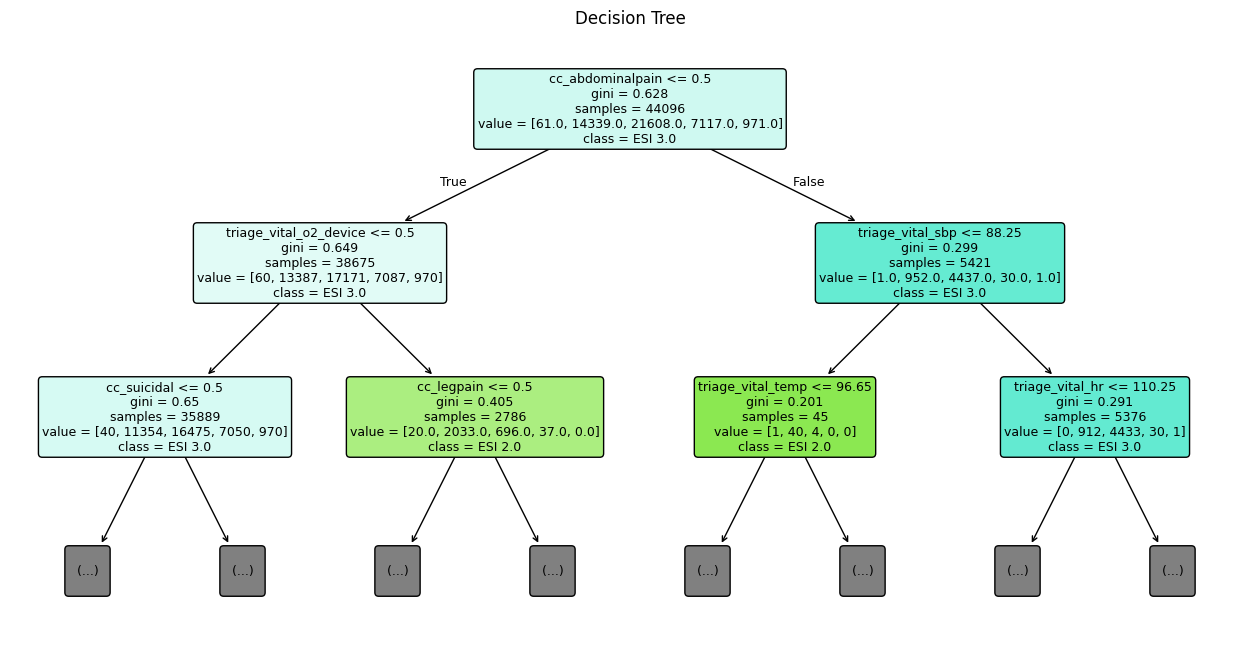

In [58]:
## Decision Tree Rules

# The decision rules generated by the trained Decision Tree are displayed as text. This allows the model's classification process to be examined more clearly.
os.makedirs("figs", exist_ok=True)

plt.figure(figsize=(16,8))


plot_tree(
    tree,
    feature_names=FEATURES,
    class_names=[f"ESI {c}" for c in tree.classes_],
    filled=True,
    rounded=True,
    max_depth=2,
    fontsize=9
)


plt.title("Decision Tree")

plt.savefig(
    "figs/w6_decision_tree.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()

In [59]:
# Print tree rules

print(
    export_text(
        tree,
        feature_names=list(FEATURES),
        max_depth=3
    )
)

|--- cc_abdominalpain <= 0.50
|   |--- triage_vital_o2_device <= 0.50
|   |   |--- cc_suicidal <= 0.50
|   |   |   |--- cc_alcoholintoxication <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- cc_alcoholintoxication >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- cc_suicidal >  0.50
|   |   |   |--- cc_headache-recurrentorknowndxmigraines <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- cc_headache-recurrentorknowndxmigraines >  0.50
|   |   |   |   |--- class: 3.0
|   |--- triage_vital_o2_device >  0.50
|   |   |--- cc_legpain <= 0.50
|   |   |   |--- cc_chestpain <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- cc_chestpain >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- cc_legpain >  0.50
|   |   |   |--- cc_breathingdifficulty <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- cc_breathingdifficulty >  0.50
|   |   |   |   |--- class: 2.0
|---

In [60]:
## Save Trained Models

# The trained Logistic Regression model, Decision Tree model, and feature scaler are saved using Joblib.

# Saving the models allows them to be reused later without needing to retrain them.
joblib.dump(
    logreg,
    "model_logreg.joblib"
)

joblib.dump(
    tree,
    "model_tree.joblib"
)

joblib.dump(
    scaler,
    "scaler.joblib"
)


print("Models saved successfully.")

Models saved successfully.


In [61]:
## Reload Saved Models

# The saved models are loaded back into the notebook and tested to confirm that they produce the same predictions as the original trained models.
logreg_reloaded = joblib.load("model_logreg.joblib")
tree_reloaded = joblib.load("model_tree.joblib")
scaler_reloaded = joblib.load("scaler.joblib")


example = X_test.iloc[:5]

example_scaled = scaler_reloaded.transform(example)


print(
    "Reloaded logreg predictions:",
    logreg_reloaded.predict(example_scaled)
)

print(
    "Reloaded tree predictions:",
    tree_reloaded.predict(example)
)


print(
    "Reloaded model matches original?",
    (
        logreg_reloaded.predict(example_scaled)
        ==
        logreg.predict(scaler.transform(example))
    ).all()
)

Reloaded logreg predictions: [2. 3. 3. 2. 2.]
Reloaded tree predictions: [2. 3. 3. 3. 3.]
Reloaded model matches original? True


## 8 · Exercises
1. Re-run the split with a **different `random_state`**. Do the accuracies move a little? Why?
2. Change the tree's `max_depth` to 3, then to 12. What happens to training vs test accuracy — and to how readable the tree picture is?
3. In one sentence: why did we scale for logistic regression but not for the tree?
4. Look at your tree image: what is the **first feature** it splits on, and why might that be clinically sensible for triage?
5. In the logistic-regression picture, which corner of the plot is ‘urgent’? Swap `f1`/`f2` for two other vitals — does the line separate the classes better or worse?

   ## Answer

1) Yes, the accuracies changed slightly because changing the random_state creates a different training and testing split. The model learns from different patients each time, which can slightly affect performance.

2) With max_depth=3, the decision tree became simpler and easier to interpret but may have lower accuracy because it had fewer decision rules. With max_depth=12, the training accuracy increased because the tree learned more details from the data, but it became more complex and had a higher risk of overfitting. The deeper tree was also harder to read and explain.

3) Features were scaled for logistic regression because it is affected by different feature ranges, while scaling was not needed for the decision tree because it uses feature splits and is not affected by feature size.

4) The first feature the decision tree splits on is cc_abdominalpain. This is clinically sensible because abdominal pain is a common emergency department complaint and can represent conditions ranging from minor issues to serious medical emergencies requiring urgent assessment.

5) The first logistic regression plot used triage_vital_temp and triage_vital_hr as the two features. The urgent patients (ESI 1-2) are represented by the red region of the plot. After changing the second feature from triage_vital_hr to triage_vital_o2, the decision boundary changed. The combination of triage_vital_temp and triage_vital_o2 separated the urgent and non-urgent classes better because oxygen saturation is more closely related to patient severity.

In [62]:
## Conclusion

# This notebook demonstrated the development of two baseline machine learning models for predicting Emergency Severity Index levels. Logistic Regression achieved the highest predictive accuracy, while the Decision Tree provided a more interpretable model structure. The models were successfully trained, visualised, saved, and reloaded for future use.